### Пусть $\xi_1, \xi_2,...$ - последовательность независимых случайных величин из хи-квадрат распределения с 3 степенями свободы.   
### Привести графическую иллюстрацию центральной предельной теоремы.

In [57]:
import numpy as np
import matplotlib.pyplot as plt

def sample(N):

    xi = np.random.chisquare(df=3, size=N)

    S_n = np.cumsum(xi)

    sample_mean = S_n / np.arange(1, N+1)

    return sample_mean

В предыдущем ноутбуке было много времени уделено теории, так что теперь просто напишем формулировку центральной предельной теоремы.

$$Z_n = \frac{S_n - \mathbb{E}(S_n)}{\sqrt{n \mathbb{D}(\xi_1)}} \xrightarrow{d} \eta \sim N(0,1), \ n \rightarrow \infty$$

Соответственно нужно показать, что функция распределения случайной величины $Z_n$ с увеличением n все больше похожа на функцию распределения случайной величины со стандартным нормальным распределнием.

Очень кстати будет вспомнить графики из предыдущего ноутбука:

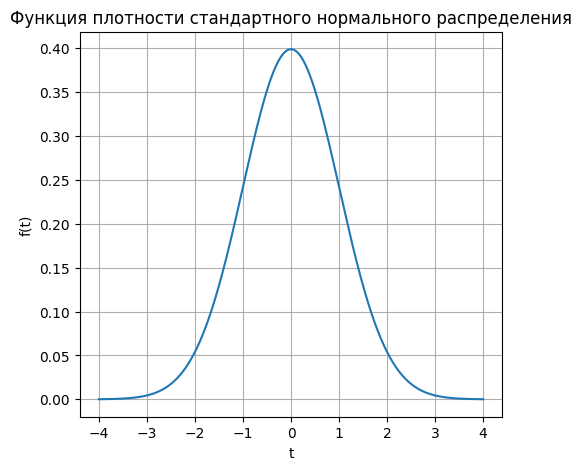

In [58]:
from scipy.stats import norm

t = np.linspace(-4,4,1000)

pdf = norm.pdf(t)
cdf = norm.cdf(t)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(t, pdf)
plt.title("Функция плотности стандартного нормального распределения")
plt.xlabel("t")
plt.ylabel("f(t)")
plt.grid()

plt.show()

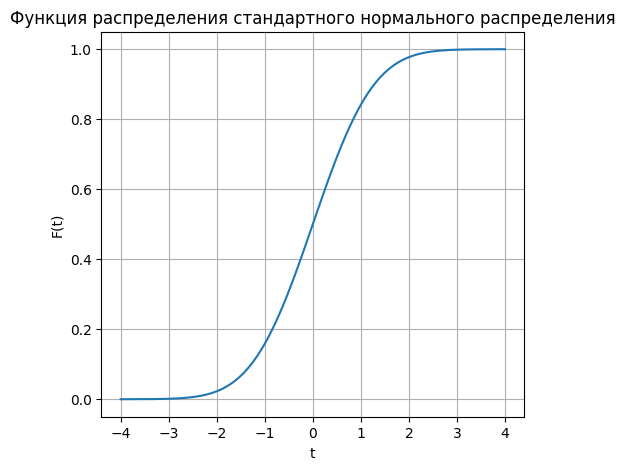

In [59]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(t, cdf)
plt.title("Функция распределения стандартного нормального распределения")
plt.xlabel("t")
plt.ylabel("F(t)")
plt.grid()

plt.show()

Напишем функцию генерации случайной величины $Z_n$, причем такую, чтобы по итогу мы получали уже нормированные значения (для различных $n$ будем проводить по $M$ симуляций, как это было в конце предыдущего задания)

Нормировать будем с помощью центрирования и нормировки: $$X_{norm} = \frac{X - \mathbb{E}(X)}{\sqrt{\mathbb{D}(X)}}$$

In [60]:
def Zn(n, M=10000):
    
    mu = 3
    disp = 6
    
    Z = []
    
    for _ in range(M):
        
        sample = np.random.chisquare(df=3, size=n)
        
        S_n = sum(sample)
        
        Z_n = (S_n - n * mu) / np.sqrt(n * disp)
        
        Z.append(Z_n)
    
    return np.array(Z)

Напишем функцию, строющую гистограммы нормированных сумм.

In [61]:
def plot_Zn_histograms(n_values, M=30000):

    fig, axes = plt.subplots(2, 5, figsize=(18, 7))
    axes = axes.flatten()

    x = np.linspace(-4, 4, 400)

    for i, n in enumerate(n_values):

        Z = Zn(n, M)

        axes[i].hist(Z, bins=40, density=True, alpha=0.6)
        axes[i].plot(x, norm.pdf(x))

        axes[i].set_title(f"n = {n}")
        axes[i].grid(True)

    plt.tight_layout()
    plt.show()

In [62]:
n_values = [5 * 2**i for i in range(10)]

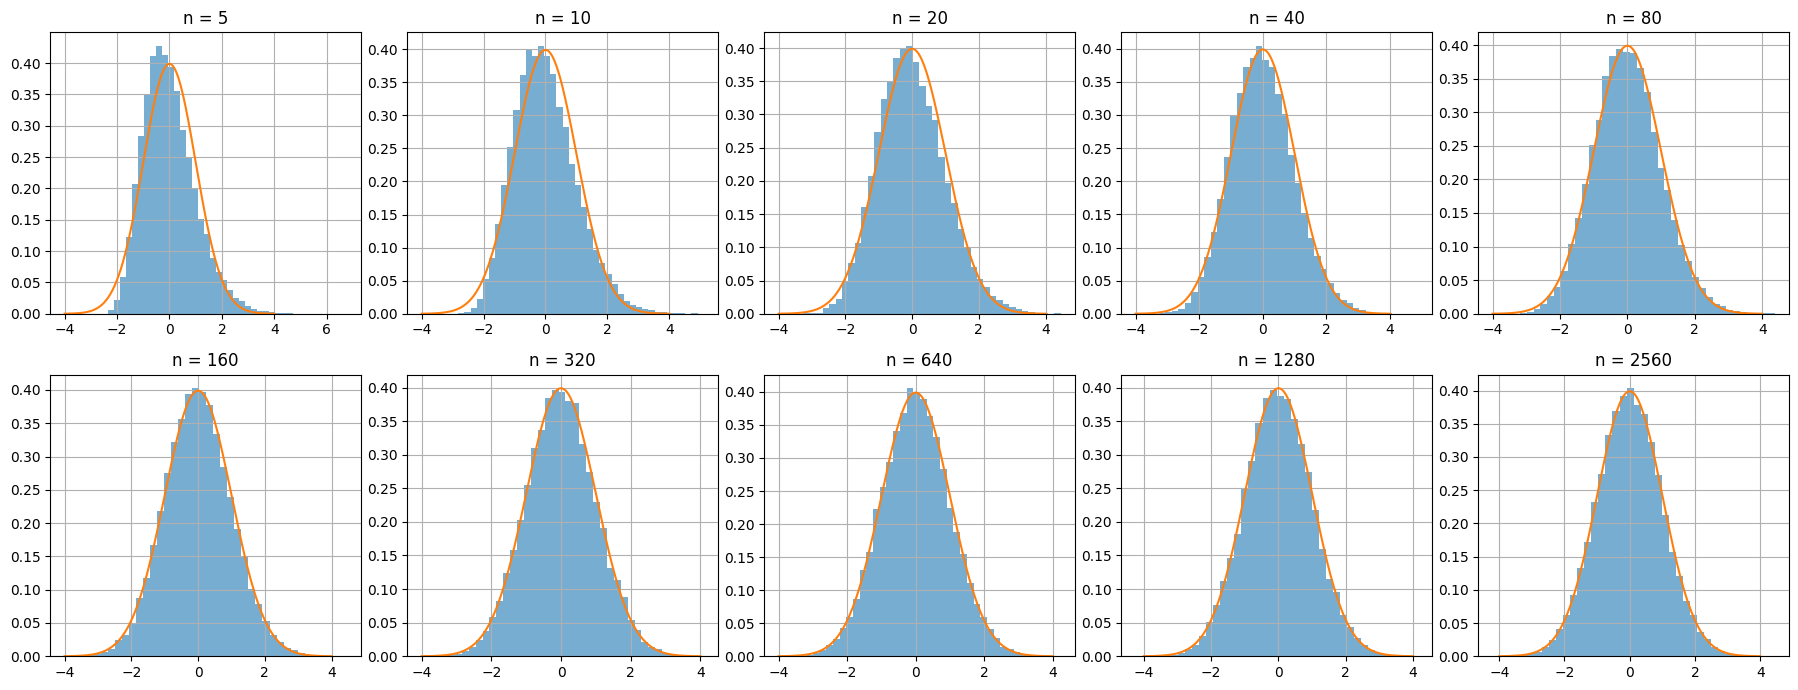

In [63]:
plot_Zn_histograms(n_values)

Заметим, что с увеличением $n$ гистограмма все больше совпадает с графиком плотности стандартного нормального распределения.  
В последнем представлении даже некоторые подобия выбросов сошли на нет.

Теперь построим графики эмпирических функций распределения.

$F^*_{n,M}(t) = \frac{1}{M} \sum_{i=1}^{M} \mathbb{I} (Z_n < t)$

И так как эмпирическая функция распределения почти навернео сходится к функции распределения с увеличением $n$, то мы должны получить совпадение графиков на последних итерациях.

$$\sup_{t \in \mathbb{R}}|F^*_n(t) - F(t)| \xrightarrow{п.н.} 0 , \  \ n \rightarrow \infty$$

In [64]:
def ecdf(sample):
    
    x = np.sort(sample)
    y = np.arange(1, len(x) + 1) / len(x)
    
    return x, y

В этом случае возьмем M = 500, значительно ее уменьшив. В противном случае будет трудно увидеть отличия между первым и последним графиками.

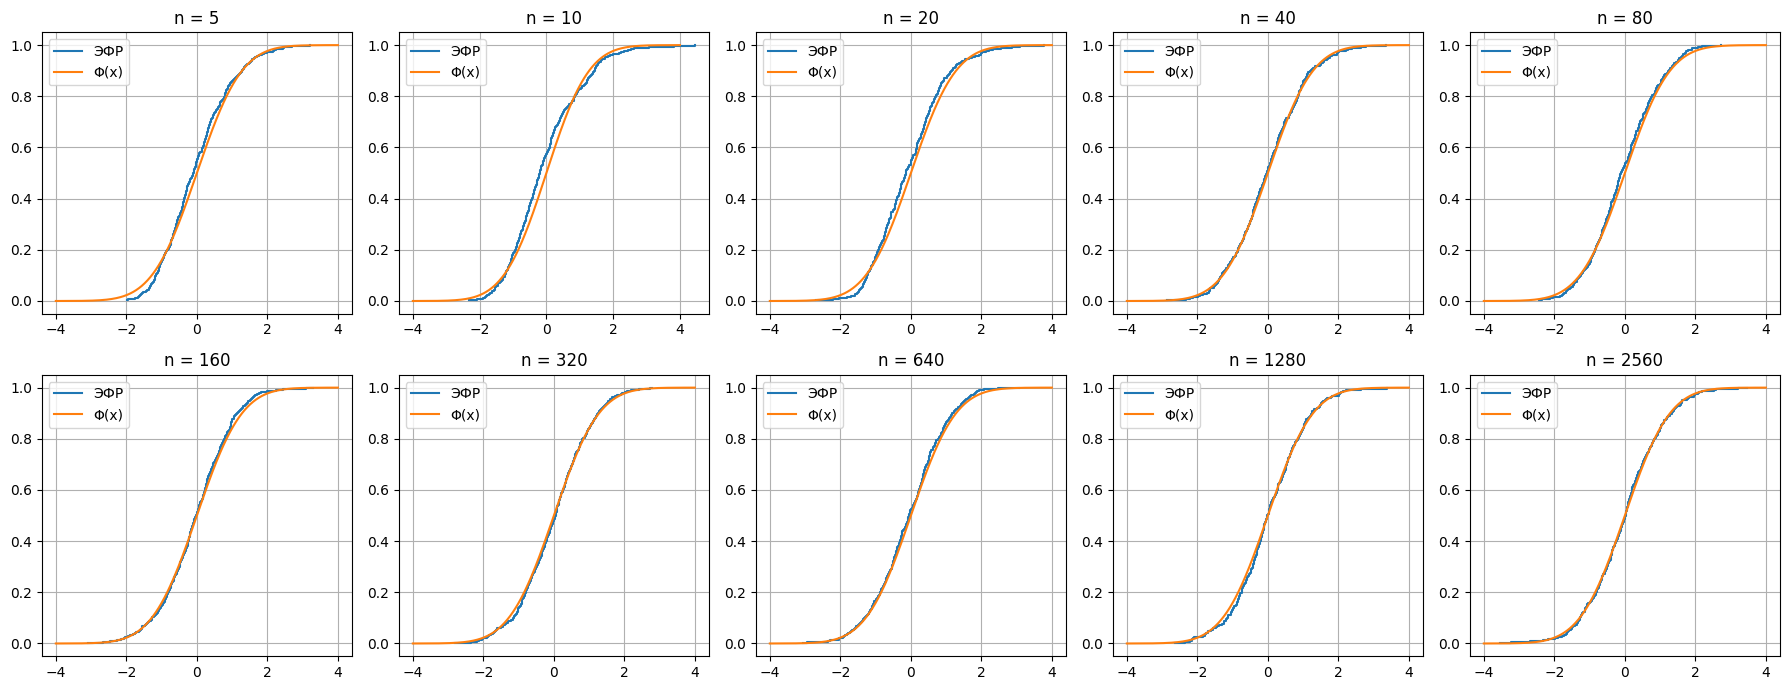

In [65]:
def plot_ecdf_Zn(n_values, M=500):
    
    fig, axes = plt.subplots(2, 5, figsize=(18, 7))
    axes = axes.flatten()

    x_theor = np.linspace(-4, 4, 500)
    y_theor = norm.cdf(x_theor)

    for i, n in enumerate(n_values):

        Z = Zn(n, M)

        x_emp, y_emp = ecdf(Z)

        axes[i].step(x_emp, y_emp, where='post', label='ЭФР')
        axes[i].plot(x_theor, y_theor, label='Φ(x)')

        axes[i].set_title(f'n = {n}')
        axes[i].grid(True)
        axes[i].legend()

    plt.tight_layout()
    plt.show()

plot_ecdf_Zn(n_values)

Как мы и предполагали - с увеличением выборки ЭФР все больше похожа на функцию распределения стандартного нормального распределения.

Теперь осталось "посчитать" расстояние между нашим ЭФР и функцией распределения стандартного нормального распределения.  
Так как теоретически при увеличении n к $\infty$ разница между $F^*$ и $F$ должна стремиться к 0, то, следовательно, и расстояние должно стремиться к 0.

Воспользуемся для этой оценки расстоянием Колмогорова: 
$$d_n = \sup_{t}|F_n(t) - \Phi(t)|$$

In [66]:
def kolmogorov_distance(sample):
    
    x = np.sort(sample)
    m = len(x)
    
    max_diff = 0
    
    for i in range(m):
        
        F_emp = (i + 1) / m
        F_theor = norm.cdf(x[i])
        
        diff = abs(F_emp - F_theor)
        
        if diff > max_diff:
            max_diff = diff
    
    return max_diff

In [67]:
distances = []

for n in n_values:
    Z = Zn(n)
    d = kolmogorov_distance(Z)
    distances.append(d)

print(distances)

[np.float64(0.05823331078597105), np.float64(0.034548742722758985), np.float64(0.03191431830398783), np.float64(0.016082817698933938), np.float64(0.016768358741423572), np.float64(0.01664500535420721), np.float64(0.013813923093436431), np.float64(0.011348626376676663), np.float64(0.008356514128886383), np.float64(0.008054437283562199)]


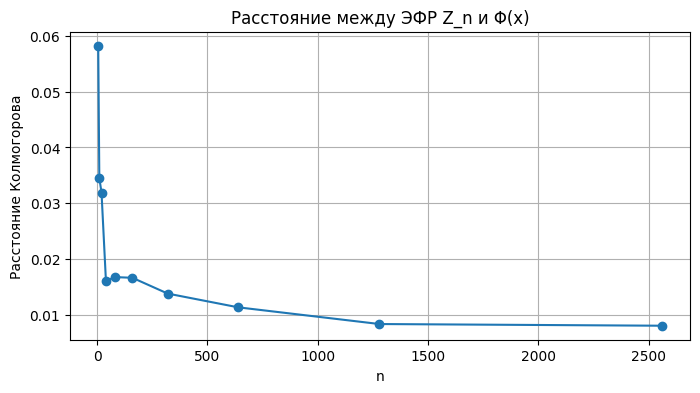

In [69]:
plt.figure(figsize=(8, 4))
plt.plot(n_values, distances, marker='o')
plt.xlabel('n')
plt.ylabel('Расстояние Колмогорова')
plt.title('Расстояние между ЭФР Z_n и Φ(x)')
plt.grid()
plt.show()

Видим, что с увеличенеим $n$ расстояние действительно уменьшается, что свидетельствует о истинности ЦПТ.